# 01. Neural Network Regression with Tensorflow

Imagine your brain: It has billions of tiny cells called neurons that connect and send signals to each other. They "talk" to figure out things like "Is that a smile?" or "Should I run from that shadow?"

A neural network is a computer version of that. It's like a bunch of fake brain cells (math-based "neurons") wired together in a web. Here's how it works in simple steps:

1. **Input (What You Feed It):** You give it data, like a photo of a cat. Each part of the photo (colors, shapes) goes into the first layer of neurons.

2. **Layers of Neurons (The Thinking Part):**

    - The network has **layers** stacked like a sandwich:
    
        - **Input Layer:** Grabs the raw data (e.g., pixel by pixel of the photo).
        - **Hidden Layers (the "deep" part):** These are the magic middle layers. Each neuron here looks at a bit of info, does simple math (like adding weights or biases—think of it as "importance scores"), and passes a signal to the next layer. They learn patterns, like "whiskers + fur = probably a cat."
        - **Output Layer:** Spits out the answer, like "90% sure it's a cat."
    
    - More layers = "deeper" network = better at spotting complex stuff (that's deep learning!).

3. **Learning (How It Gets Smart):** At first, it's dumb and guesses wrong. You tell it "Nope, that's a dog!" and it tweaks its connections (adjusts those "weights") to do better next time. Repeat this with tons of examples, and it learns—like practicing a skill until you're a pro.

**Resources:** 

- [MIT 6.S191 Introduction to Deep Learning](https://www.youtube.com/playlist?list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI)

### Typical architecture of a regresison neural network

| Hyperparameter | Typical value |
| -------------- | ------------- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/code/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

*Table 1: Typical architecture of a regression network. Source: Adapted from page 293 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632)*

> **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

### What is a regression?

**Regression** is a type of problem in machine learning and statistics where we try to predict a number (a continuous value) based on input data.

**Key idea:**

You're trying to find a relationship between the input(s) (like size of a house) and the output (like its price), so that when you get new input data, you can predict the output.

**Real-life examples of regression:**

- Predicting the price of a house based on its size, location, and number of rooms.
- Estimating temperature tomorrow based on weather data.
- Predicting a student’s score based on hours studied.
- Forecasting sales based on advertising budget and past trends.

In [23]:
import tensorflow as tf

In [2]:
tf.__version__

'2.19.1'

### Create Data to View and Fit

In [3]:
import numpy as np
import matplotlib.pyplot as plt

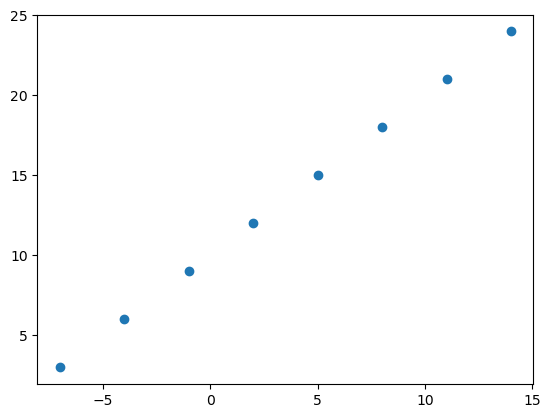

In [4]:
# create features
X = np.array([-7,-4,-1,2,5,8,11,14])

# create labels
y = np.array([3,6,9,12,15,18,21,24])

# visualize
plt.scatter(X, y)

### Input and Output Shapes

In [24]:
# create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([930700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([930700], dtype=int32)>)

In [6]:
# turn our numpy arrays into tensors
X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=int64, numpy=array([-7, -4, -1,  2,  5,  8, 11, 14])>,
 <tf.Tensor: shape=(8,), dtype=int64, numpy=array([ 3,  6,  9, 12, 15, 18, 21, 24])>)

### Steps in Modelling with Tensorflow

In [34]:
tf.random.set_seed(42)

# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["mae"])

# fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100, verbose=0)
print("Model Fitted!")

Model Fitted!


In [8]:
# make a prediction
y_preds = model.predict(tf.constant([17.0]))
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[26.959595]], dtype=float32)

### Imporving the Model

Improving a TensorFlow model involves optimizing its architecture, training process, and data handling to enhance performance, reduce overfitting, and increase efficiency. Below is a list of key methods with short descriptions:

1. **Hyperparameter Tuning**


   Adjust learning rate, batch size, or number of epochs using tools like Keras Tuner to find optimal settings for better convergence and performance.

3. **Data Augmentation**

    Apply transformations (e.g., rotation, flipping for images) to increase dataset diversity, reducing overfitting and improving generalization.

3. **Regularization**

    Use techniques like L2 regularization or Dropout (e.g., tf.keras.layers.Dropout(0.2)) to prevent overfitting by penalizing large weights or randomly dropping neurons.

4. **Batch Normalization**

    Add tf.keras.layers.BatchNormalization to normalize layer inputs, stabilizing and accelerating training while reducing sensitivity to initialization.

5. **Advanced Optimizers**

    Experiment with optimizers like AdamW, RMSprop, or SGD with momentum instead of default Adam for better convergence on specific tasks.

6. **Model Architecture Optimization**

    Use deeper or wider networks, or task-specific layers (e.g., Conv2D for images, LSTM for sequences) to better capture data patterns.

7. **Transfer Learning**

    Use pre-trained models (e.g., tf.keras.applications.ResNet50) and fine-tune on your dataset to leverage learned features, especially with limited data.

8. **Early Stopping**

    Implement tf.keras.callbacks.EarlyStopping to halt training when validation performance stops improving, preventing overfitting.

9. **Learning Rate Scheduling**

    Use tf.keras.callbacks.ReduceLROnPlateau or custom schedules to adjust the learning rate dynamically, improving convergence.

10. **Increase Dataset Quality/Size**

    Clean data, remove noise, or gather more samples to provide the model with better and more diverse training examples.

11. **Feature Engineering**

    Create or select more relevant features (e.g., scaling, encoding) to improve the model’s ability to learn meaningful patterns.

12. **Ensemble Methods**

    Combine predictions from multiple models (e.g., averaging or stacking) to boost accuracy and robustness.

13. **Mixed Precision Training**

    Enable mixed precision with tf.keras.mixed_precision to speed up training and reduce memory usage while maintaining accuracy.

14. **Cross-Validation**

    Use k-fold cross-validation to evaluate model performance more reliably and reduce variance in performance estimates.

15. **Monitor with TensorBoard**

    Visualize training metrics (e.g., loss, accuracy) using tf.keras.callbacks.TensorBoard to diagnose issues and guide improvements.

### Evaluating a Model

TensorFlow model involves assessing its performance using various metrics and techniques. Below is a list of common evaluation methods with brief descriptions:

1. **Accuracy**

    Measures the proportion of correct predictions for classification tasks.

2. **Loss Function**

    Quantifies the difference between predicted and actual values (e.g., cross-entropy for classification, MSE for regression).

3. **Precision**

    Ratio of true positive predictions to total predicted positives, useful for imbalanced datasets.

4. **Recall**

    Ratio of true positive predictions to total actual positives, emphasizing missed positives.


5. **F1 Score**

    Harmonic mean of precision and recall, balancing both for classification tasks.

6. **Confusion Matrix**

    Table showing true vs. predicted labels to analyze classification errors.

7. **ROC-AUC**

    Area under the Receiver Operating Characteristic curve, measuring classification performance across thresholds.

8. **Mean Absolute Error (MAE)**

    Average absolute difference between predicted and actual values for regression tasks.

9. **Mean Squared Error (MSE)**

    Average squared difference between predicted and actual values, penalizing larger errors.


10. **R² Score**

    Measures the proportion of variance in the dependent variable explained by the regression model.

11. **Cross-Validation**

    Splits data into k-folds to evaluate model performance across multiple subsets.

12. **Validation Set Performance**

    Assesses model performance on a separate validation set during training to monitor generalization.

13. **Test Set Evaluation**

    Final evaluation on a held-out test set to estimate real-world performance.

14. **Learning Curves**

    Plots training and validation metrics over epochs to diagnose underfitting or overfitting.

15. **Prediction Visualization**

    Visualizes predictions (e.g., scatter plots, heatmaps) to qualitatively assess model behavior.

In [9]:
# generate random data
X = tf.range(-100, 100, 4)
y = X + 10

In [10]:
X, y

(<tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
          76,   80,   84,   88,   92,   96], dtype=int32)>,
 <tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

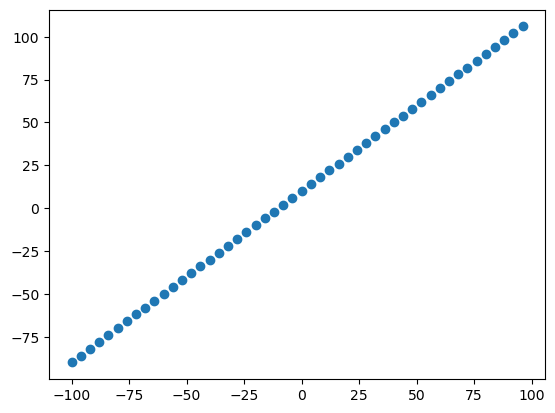

In [11]:
# visualize the data
plt.scatter(X, y)

### Splitting Dataset

1. **Training Dataset**

    - Purpose: Used to train the model.
    - What happens: The model learns patterns and adjusts its weights using this data.

2. **Validation Dataset**

    - Purpose: Used to tune the model during training.
    - What happens: Helps monitor the model's performance on unseen data while training (e.g., for early stopping, hyperparameter tuning).

3. **Testing Dataset**

    - Purpose: Used to evaluate the final model's performance.
    - What happens: The model's accuracy/generalization is checked after training to ensure it works well on completely unseen data.

In [12]:
X_train = X[:40] # 1st 40 are training samples
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples
y_test = y[40:]

len(X_train), len(y_test), len(X_test), len(y_train)

(40, 10, 10, 40)

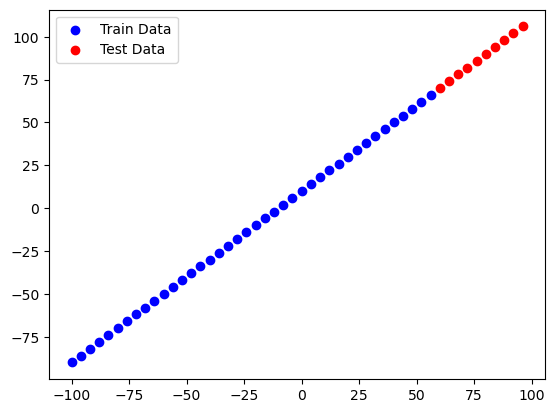

In [13]:
# visualized the data
plt.scatter(X_train, y_train, c="b", label="Train Data")
plt.scatter(X_test, y_test, c="red", label="Test Data")
plt.legend()

In [25]:
tf.random.set_seed(42)

# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")

# compile the model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["mae"])

# fit the model
model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=300, verbose=0)
print("Model Fitted!")

Model Fitted!


In [26]:
y_preds = model.predict(X_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[ 69.29106 ],
       [ 73.242546],
       [ 77.19405 ],
       [ 81.145546],
       [ 85.09703 ],
       [ 89.04852 ],
       [ 93.00002 ],
       [ 96.951515],
       [100.90299 ],
       [104.85449 ]], dtype=float32)

In [27]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

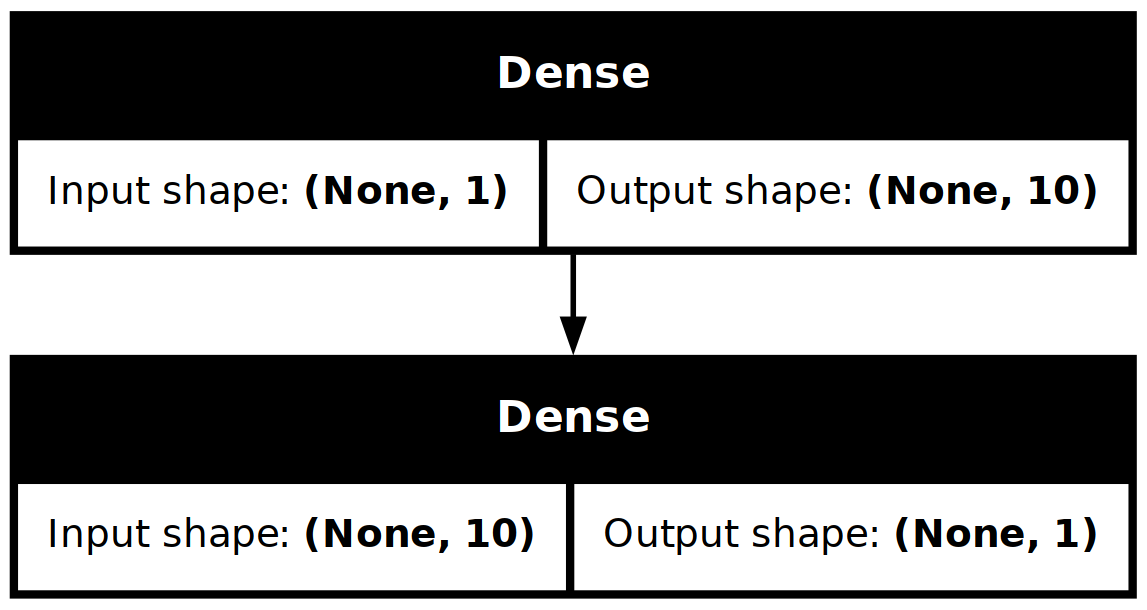

In [28]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Neural Network Weights and Biases

1. **Weights**

    Control the strength of the input data's influence.

    - Purpose: Weights determine the importance of the input features.
    
    - Role: When data flows through the network, each input is multiplied by a weight, which adjusts how much influence that input has on the output.
    
    - How it works: During training, the model learns the optimal weights that help make better predictions.
    
    - Example: In a neural network, the input might be "height" and "weight" to predict "age". Each of these inputs will have a weight that tells the model how important they are in predicting age.
  
    > output = (input_1 * weight_1) + (input_2 * weight_2)

2. **Bias**

    Shifts the output, helping the model make predictions even when inputs are zero or have low influence.

    - Purpose: Bias allows the model to adjust the output independently of the input values.
    
    - Role: It acts like an "offset" that helps the model make predictions even when the input is zero (or close to zero).
    
    - How it works: The bias is added to the weighted sum of inputs before passing it through the activation function.
    
    - Example: Imagine the input to the model is zero (e.g., no information), the bias helps push the output away from zero so that the model doesn't always output zero.
  
    > output = (input_1 * weight_1) + (input_2 * weight_2) + bias

### Visualizing our Model's Predictions

In [29]:
y_preds, y_test

(array([[ 69.29106 ],
        [ 73.242546],
        [ 77.19405 ],
        [ 81.145546],
        [ 85.09703 ],
        [ 89.04852 ],
        [ 93.00002 ],
        [ 96.951515],
        [100.90299 ],
        [104.85449 ]], dtype=float32),
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

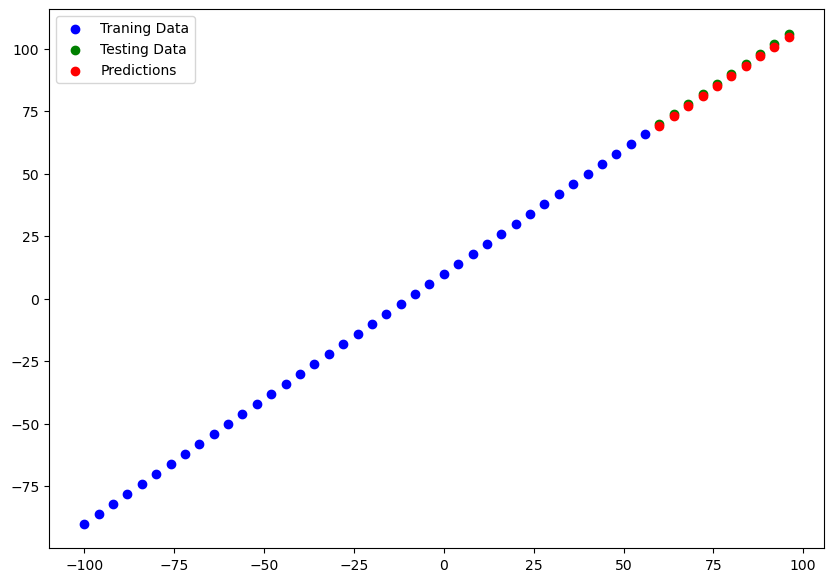

In [30]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_preds):
    """
    Plots training data, test data and compares predictions to ground truth labels
    """

    plt.figure(figsize=(10, 7))
    # plot training data
    plt.scatter(train_data, train_labels, c="b", label="Traning Data")
    # plot testing data
    plt.scatter(test_data, test_labels, c="g", label="Testing Data")
    # plot models predictions in red
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend()

plot_predictions()

### Evaluating our Model's Predictions with Regression Evalution Metrics

1. **Mean Squared Error (MSE):**

    - Measures the average of the squared differences between predicted and actual values.
    - Formula: $$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
    - TensorFlow: `tf.keras.metrics.MeanSquaredError()`
    - Use: Penalizes larger errors more heavily; widely used for regression.

2. **Mean Absolute Error (MAE)**

    - Measures the average of the absolute differences between predicted and actual values.
    - Formula: $$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
    - TensorFlow: `tf.keras.metrics.MeanAbsoluteError()`
    - Use: More robust to outliers than MSE.

3. **Root Mean Squared Error (RMSE)**

    - The square root of MSE, providing error in the same units as the target variable.
    - Formula: $$
RMSE = \sqrt{MSE}
$$
    - TensorFlow: `tf.keras.metrics.RootMeanSquaredError()`
    - Use: Interpretable in the original scale of the data.

4. **Mean Absolute Percentage Error (MAPE)**

    - Measures the average percentage difference between predicted and actual values.
    - Formula: $$
MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$
    - TensorFlow: `tf.keras.metrics.MeanAbsolutePercentageError()`
    - Use: Useful when you want errors relative to the magnitude of the actual values (avoid when `y_true` is close to zero).

5. **Mean Squared Logarithmic Error (MSLE)**

    - Measures the average of the squared logarithmic differences between predicted and actual values.
    - Formula: $$
MSLE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i + 1) - \log(\hat{y}_i + 1))^2
$$
    - TensorFlow: `tf.keras.metrics.MeanSquaredLogarithmicError()`
    - Use: Suitable for targets with exponential growth or wide-ranging values.

6. **R² Score (Coefficient of Determination)**

    - Measures the proportion of variance in the dependent variable explained by the model.
    - Formula: $$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$
    - TensorFlow: Not directly available in `tf.keras.metrics`, but can be implemented using `tf.keras.metrics.Mean` and custom logic.
    - Use: Indicates how well the model fits the data (higher is better, max 1.0).

7. **Huber Loss**

    - A loss function that is less sensitive to outliers than MSE, combining MSE and MAE properties.
    - Formula: Uses a threshold `δ` to switch between quadratic (for small errors) and linear (for large errors) loss. $$
L_\delta (y, \hat{y}) = \begin{cases} 
\frac{1}{2}(y - \hat{y})^2 & \text{for} \, |y - \hat{y}| \leq \delta \\
\delta |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}
$$
    - TensorFlow: Not a standard metric in `tf.keras.metrics`, but available as a loss function (`tf.keras.losses.Huber()`). Can be used as a metric with custom implementation.
    - Use: Balances robustness and sensitivity to errors.

8. **Log-Cosh Loss**

    - Measures the logarithm of the hyperbolic cosine of the prediction error.
    - Formula: $$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$
    - TensorFlow: Not a standard metric, but can be implemented as a custom metric.
    - Use: Smooth approximation of Huber loss, less sensitive to outliers.

In [31]:
# evaluate the model on the test sets
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.9272 - mae: 0.9272


[0.9272216558456421, 0.9272216558456421]

In [32]:
# calculate the mae
tf.keras.metrics.mae(y_test, tf.squeeze(y_preds))

<tf.Tensor: shape=(), dtype=float32, numpy=0.9272216558456421>

In [33]:
# calculate the mse
tf.keras.metrics.mse(y_test, tf.squeeze(y_preds))

<tf.Tensor: shape=(), dtype=float32, numpy=0.8791522979736328>

### Improving and Experimenting to Improve Model

- **Get more or better data:** Train on larger datasets to help the model learn patterns better. Use TensorFlow's `tf.data` API to load and preprocess data efficiently, or apply data augmentation (e.g., flipping or rotating images) `with tf.keras.layers.RandomFlip()` to create variations without collecting new data.
- **Tune hyperparameters:** Experiment with settings like learning rate, batch size, or number of layers. Use TensorFlow's `tf.keras.callbacks.EarlyStopping` to stop training when the model stops improving, or try grid search with libraries like Keras Tuner to find the best combo automatically.
- **Add regularization to prevent overfitting:** Stop the model from memorizing data instead of learning. In TensorFlow, add dropout layers with `tf.keras.layers.Dropout(0.5)` (which randomly ignores 50% of neurons during training) or use L2 regularization in the optimizer like `tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.0001)`.
- **Use a better optimizer or learning schedule:** Switch from basic Adam to something like RMSprop for faster convergence. In TensorFlow, set a learning rate schedule with `tf.keras.callbacks.ReduceLROnPlateau` to automatically lower the rate when accuracy plateaus.
- **Ensemble multiple models:** Combine predictions from several models for more reliable results. Train a few models with TensorFlow and average their outputs using simple NumPy or TensorFlow ops like `tf.reduce_mean()`.
- **Fine-tune a pre-trained model:** Start with a model trained on a huge dataset (like ImageNet) and tweak it for your task. Use TensorFlow Hub or `tf.keras.applications` to load models like ResNet, then freeze early layers with `layer.trainable = False` and train only the top ones.
- **Monitor and visualize training:** Track metrics like loss and accuracy in real-time. Use TensorFlow's `tf.keras.callbacks.TensorBoard` to log data and view interactive charts in TensorBoard, helping you spot issues early.

### Comparing the Results of Model Expirements

- **Direct metric comparison:** Train both models, then run `model_a.evaluate(test_data)` and `model_b.evaluate(test_data)` to get metrics like accuracy, loss, precision, or recall. Print or tabulate them side-by-side (e.g., Model A: 92% accuracy; Model B: 88%) to see which wins overall or per metric.
- **Plot training/validation curves:** Use `history_a = model_a.fit(...)` and `history_b = model_b.fit(...)`, then plot loss/accuracy over epochs with Matplotlib: `plt.plot(history_a.history['loss'], label='Model A')` and similarly for Model B. This shows which converges faster or overfits less.
- **Compare predictions visually:** Generate predictions with `preds_a = model_a.predict(test_data)` and `preds_b = model_b.predict(test_data)`. Plot them against true labels (e.g., scatter plot of predicted vs. actual) or compute differences with `tf.math.abs(preds_a - preds_b)` to highlight where they disagree.
- **Statistical significance test:** Compute metrics on multiple runs or cross-validation folds, then use a t-test (via SciPy: `scipy.stats.ttest_ind(scores_a, scores_b)`) on the results. This checks if one model's better performance (e.g., higher accuracy) is statistically significant, not just random.
- **ROC/AUC curve comparison:** For classification, use `tf.keras.metrics.AUC()` or scikit-learn's `roc_curve` on predictions. Plot both ROC curves on one graph (`plt.plot(fpr_a, tpr_a, label='Model A')`) and compare AUC scores—the higher one indicates better discrimination.
- **Confusion matrix side-by-side:** Get predictions, then create matrices with `tf.math.confusion_matrix(true_labels, preds_a)` and for Model B. Plot them as heatmaps next to each other (using `seaborn.heatmap`) to compare error types, like which model misclassifies more in certain categories.
- **Inference speed and efficiency:** Time predictions with `start = time.time(); model_a.predict(test_data); time_a = time.time() - start` (and same for Model B). Compare times, or use `tf.profiler` to log FLOPs/memory—great for picking the faster one for real-world use.

### Saving Model

- **SavedModel format (recommended for production):** Saves the entire model (architecture, weights, and config) in a portable directory. Use `model.save('my_model')` to save, and `tf.saved_model.load('my_model')` to load. It's great for serving with TensorFlow Serving or exporting to other frameworks.
- **HDF5 format (.h5):** Stores the model architecture and weights in a single file. Call `model.save('my_model.h5')` to save, and `tf.keras.models.load_model('my_model.h5')` to load. Ideal for quick saves during experiments.
- **Weights only:** Save just the trained parameters (not the full architecture) to reuse in another model. Use `model.save_weights('my_weights.h5')` to save, and `model.load_weights('my_weights.h5')` to load. This keeps files small but requires rebuilding the model structure first.
- **TensorFlow Lite (.tflite) for mobile/edge devices:** Convert and save a lightweight version optimized for inference on phones or IoT. Run `converter = tf.lite.TFLiteConverter.from_keras_model(model); tflite_model = converter.convert(); with open('my_model.tflite', 'wb') as f: f.write(tflite_model)`. Load with the TFLite interpreter.
- ONNX format for cross-framework use: Export to the Open Neural Network Exchange standard for compatibility with other tools like PyTorch. Use `tf2onnx.convert.from_keras(model, output_path='my_model.onnx')` (requires the tf2onnx package). Load in ONNX Runtime or similar.
- **Save Model with Checkpoints (for Training):** If you want to save checkpoints during training (useful for resuming training or fine-tuning), you can use ModelCheckpoint during training. This saves the model at regular intervals based on the validation performance.

    ```Python
    from tensorflow.keras.callbacks import ModelCheckpoint
    
    checkpoint = ModelCheckpoint('model_checkpoint.h5', save_best_only=True, monitor='val_loss', mode='min')
    
    model.fit(train_data, train_labels, validation_data=(val_data, val_labels), epochs=10, callbacks=[checkpoint])
    ```
- **Save the Model with a Custom Callback (for Advanced Scenarios):** You might want to save the model at specific points during training based on custom logic (e.g., based on loss or accuracy at specific intervals).

    ```Python
    class CustomSaveCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if logs.get('val_loss') < 0.2:  # Custom condition
                self.model.save(f"custom_model_{epoch}.h5")
    
    # Use the custom callback in training
    custom_callback = CustomSaveCallback()
    model.fit(train_data, train_labels, epochs=10, callbacks=[custom_callback])
    ```